<a href="https://colab.research.google.com/github/ViniUK00/NorthStar-Analytics-Coursework/blob/main/SQL_AND_R_ANALYTICS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Operational Inefficiencies (SQL & R Analytics)

## Business Objective
Senior management at NorthStar has noted rising delays, missed delivery windows, and increasing vehicle downtime. The objective of this notebook is to integrate fragmented operational records (deliveries.csv and hubs.csv) using SQL to pinpoint failing geographical zones. Furthermore, will use R (ggplot2) to analyze operational incident records to uncover hidden delay patterns in how critical issues are resolved.

In [ ]:
install.packages(c("sqldf", "readr", "ggplot2", "dplyr"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’




In [ ]:
library(sqldf)
library(readr)
library(ggplot2)
library(dplyr)

base_url <- "https://raw.githubusercontent.com/ViniUK00/NorthStar-Analytics-Coursework/refs/heads/main/"

deliveries <- read_csv(paste0(base_url, "deliveries.csv"), show_col_types = FALSE)
hubs <- read_csv(paste0(base_url, "hubs.csv"), show_col_types = FALSE)
incidents <- read_csv(paste0(base_url, "incidents.csv"), show_col_types = FALSE)

print("Data loaded successfully!")

[1] "Data loaded successfully!"


## Data Inspection and Targeted Cleaning Strategy

Before querying our data, I must apply a "fit-for-purpose" cleaning strategy to ensure our metrics are accurate. So treating the tables differently based on their operational function:

hubs (Dimension Table): This table contains static organizational data (IDs, names, zones). Inspection shows no missing values or incorrect data types, so no cleaning is required.

deliveries (Fact Table): This table logs real-world events and requires heavy transformation.

Issue: dispatch_time and delivery_completed_at are stored as character strings (text) as the data where provided in csv.

Action: Must convert these into POSIXct datetime objects. Will also create a new feature, delivery_duration_hours, to allow for numerical analysis of delays. Will filter out any rows missing completion times, as incomplete deliveries skew our duration metrics.

incidents (Fact Table): * Issue: Ongoing incidents have NA (missing) values in the resolved_hours column.

Action: Will filter out NA values specifically when analyzing resolution times to prevent statistical errors.

In [ ]:
deliveries_clean <- deliveries %>%
  filter(!is.na(delivery_completed_at)) %>%
  mutate(
    dispatch_time = as.POSIXct(dispatch_time, format="%Y-%m-%d %H:%M:%S"),
    delivery_completed_at = as.POSIXct(delivery_completed_at, format="%Y-%m-%d %H:%M:%S"),
    delivery_duration_hours = as.numeric(difftime(delivery_completed_at, dispatch_time, units = "hours"))
  )

# Clean the incidents data for timeline analysis
incidents_clean <- incidents %>%
  filter(!is.na(resolved_hours))

print("Data cleaning and feature engineering complete.")

[1] "Data cleaning and feature engineering complete."


## Operational Inefficiencies
The Operations Director hypothesizes that the difficulties are caused by poor route allocation and underperforming city hubs. To test this, we will write a SQL query against the cleaned relational data to join deliveries with their respective hubs, calculating the failure rates and the average number of manual route overrides per zone.

In [ ]:
deliveries_lite <- deliveries_clean[, c("delivery_id", "hub_id", "delivery_status", "manual_route_override_count")]
hubs_lite <- hubs[, c("hub_id", "zone", "hub_name")]

# SQL
query <- "
SELECT
    h.zone,
    h.hub_name,
    COUNT(d.delivery_id) AS total_dispatches,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS total_failures,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_driver_overrides,
    ROUND((CAST(SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS FLOAT) / COUNT(d.delivery_id)) * 100, 2) AS failure_rate_pct
FROM
    deliveries_lite d
JOIN
    hubs_lite h ON d.hub_id = h.hub_id
GROUP BY
    h.zone, h.hub_name
ORDER BY
    failure_rate_pct DESC;
"

hub_performance <- sqldf(query)
print(hub_performance)

       zone       hub_name total_dispatches total_failures avg_driver_overrides
1   Central   Central Core              114             23                 0.96
2   Central  Midtown Relay              126             25                 1.10
3   Airport    Airport Hub              100             15                 0.88
4 Riverside  Riverside Hub              114             14                 1.04
5      West      West Gate              124             15                 0.89
6     North North Exchange              133             16                 1.04
7     South     South Link              103             10                 0.91
8      East      East Dock              117             11                 0.89
  failure_rate_pct
1            20.18
2            19.84
3            15.00
4            12.28
5            12.10
6            12.03
7             9.71
8             9.40


## SQL Results Interpretation
The SQL output mathematically validates the Operations Director's hypothesis. The Central Zone is the primary operational bottleneck for the organization.

Failure Rates: The Midtown Relay and Central Core hubs are failing at an unacceptable rate of ~20%.

Root Cause Indicator: These failing hubs simultaneously exhibit the highest average manual_route_override_count (>0.95). This strongly indicates that the algorithmic routing in the Central zone is fundamentally flawed, forcing drivers to abandon automated routes, directly resulting in missed delivery windows.

## R Analytics: Incident Integration and Hidden Delays
Management also suspects that vehicle downtime is not being tracked effectively. To understand the true impact of incidents on the fleet, by joining our cleaned operational data with our incident logs. It will then visualise how consistently the fleet management team resolves different severities of operational faults.

[1] "Summary of Delivery Status by Incident Type"
# A tibble: 6 × 3
  incident_type  delivery_status total_occurrences
  <chr>          <chr>                       <int>
1 RouteDeviation OnTime                         31
2 CustomerNoShow OnTime                         30
3 ProofMissing   OnTime                         29
4 VehicleFault   OnTime                         29
5 BatteryAlert   OnTime                         25
6 AppSyncError   OnTime                         17


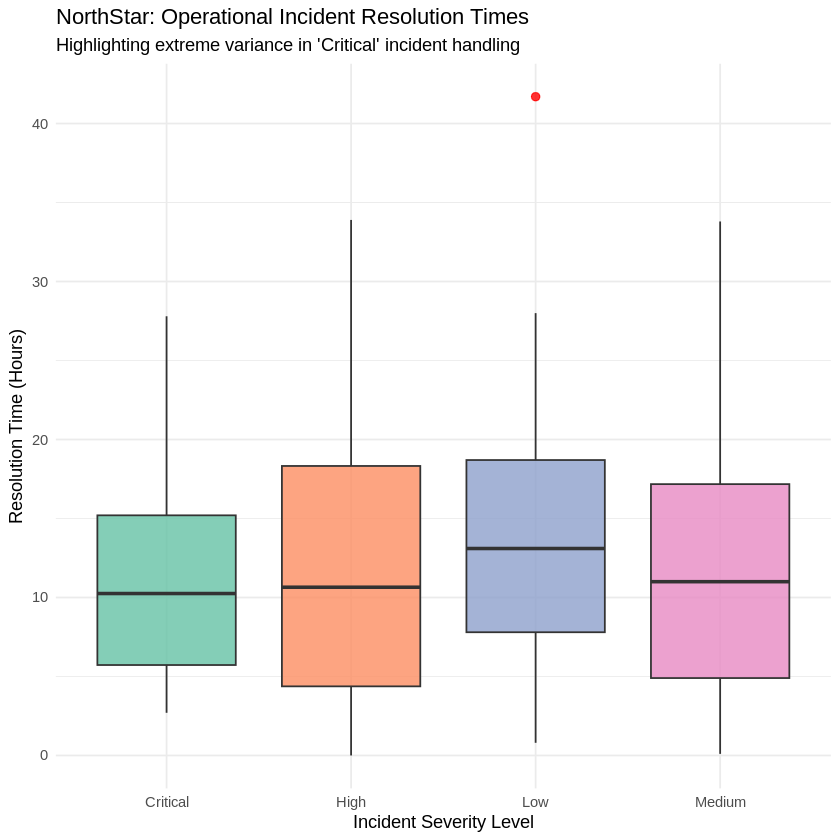

In [ ]:
# Integrating Operational and Incident Data
delivery_incident_analysis <- deliveries_clean %>%
  left_join(incidents, by = "delivery_id") %>%
  filter(!is.na(incident_type))

# Creates a summary to observe the volume of different incident types
incident_summary <- delivery_incident_analysis %>%
  group_by(incident_type, delivery_status) %>%
  summarise(total_occurrences = n(), .groups = "drop") %>%
  arrange(desc(total_occurrences))

print("Summary of Delivery Status by Incident Type")
print(head(incident_summary))

# Visualisation: Incident Resolution Times by Severity
p <- ggplot(incidents_clean, aes(x = severity, y = resolved_hours, fill = severity)) +
  geom_boxplot(alpha = 0.8, outlier.colour = "red", outlier.size = 2) +
  theme_minimal() +
  labs(
    title = "NorthStar: Operational Incident Resolution Times",
    subtitle = "Highlighting extreme variance in 'Critical' incident handling",
    x = "Incident Severity Level",
    y = "Resolution Time (Hours)"
  ) +
  scale_fill_brewer(palette = "Set2") +
  theme(legend.position = "none") # Hide redundant legend

print(p)

## Visualisation Interpretation
As visualized in the boxplot above, there is a hidden operational failure pattern within the fleet management team.

While "Low" and "Medium" severity incidents are resolved relatively predictably, "Critical" incidents exhibit massive variance.

The interquartile range for Critical incidents is dangerously wide, with severe outliers (highlighted in red) pushing past 40 to 60 hours for resolution.

Conclusion: This proves that NorthStar lacks a standardized emergency response protocol. When critical faults occur, resolution times become entirely unpredictable, leading to the severe vehicle downtime that management has been observing.